# Part 2 -- Model Scaling Law on DarijaDZ

Companion to `../scaling_laws_lab.md` Part 2 and `../plan.md`'s Part 2 section.
**Deviations from the lab doc's original suggestions, each deliberate:**

1. **Fixed data budget D=50M tokens** (user-specified) -- large enough that every model in
   the sweep stays comfortably above its own compute-optimal point (checked explicitly
   below, not assumed).
2. **NOT word2vec-initialized** (unlike Part 1) -- word2vec's checkpoint is pinned to
   `embed_dim=128`, so it can only fit one point in a sweep that varies `d_model`; using it
   there and not elsewhere would confound "bigger model" with "this one model also got a
   pretrained head start." Every model here starts from the same random-init recipe, so
   model size is the only thing varying.
3. **Aspect-ratio family: `d_model in {32, 64, 96, 128, 160}`, `head_dim=32`** (not the
   `{64,...,320}`/`head_dim=64` family originally sketched in `plan.md`) -- under a fixed
   `d_model/n_layer` aspect ratio, non-embedding params grow roughly as `d_model^3`, so the
   wider family would have put its two largest points deep in the *data-limited* regime at
   D=50M (compute-optimal-D/D ratios of 0.4x and 0.2x -- badly over-parameterized for this
   budget). This narrower family keeps every point's margin at 1.6x or better -- see the
   margin table below, computed for real, not assumed.
4. **Embeddings still NOT tied** (same as Part 1) -- `tok_embedding` and `lm_head` are
   separate matrices, which is what makes the total-vs-non-embedding-params comparison this
   part is actually about well-defined in the first place.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SCRIPTS_DIR = Path.cwd().parent / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
from train import train_one_subset  # noqa: E402
from model import DecoderLM  # noqa: E402

DATA_DIR = Path.cwd().parent / "data"
FIXED_D = 50_000_000
MODEL_CONFIGS = [(32, 1, 1), (64, 2, 2), (96, 3, 3), (128, 4, 4), (160, 5, 5)]

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

meta = json.loads((DATA_DIR / "meta.json").read_text(encoding="utf-8"))
meta

CUDA available: True
GPU: NVIDIA GeForce RTX 2060


{'tokenizer_key': 'unigram',
 'tokenizer_vocab_size': 20000,
 'tokenizer_model_dir': 'Tokenization/models_bigcorpus/sentencepiece',
 'pad_id': 0,
 'bos_id': 2,
 'eos_id': 3,
 'heldout_docs': 16419,
 'heldout_tokens': 300030,
 'train_pool_docs': 2703141,
 'train_pool_tokens': 50050097,
 'subset_sizes': [100000, 300000, 1000000, 3000000, 10000000],
 'source_corpus': 'Data\\youtube_corpus_shuffled.jsonl'}

## Compute-optimal margin check (real, not assumed)

For each config: non-embedding params (from an actual instantiated model, not the
`12*d_model^2*n_layer` approximation), the Chinchilla-heuristic compute-optimal data size
(~20 tokens/param), and the margin `D / compute_optimal_D` -- values well above 1x mean the
model is safely in the data-limited-for-this-N-is-not-yet-a-problem regime; values near or
below 1x mean D=50M is not enough data for that model size, and its loss will be biased
upward by data scarcity, not just reflect its capacity.

In [2]:
rows = []
for d_model, num_heads, num_layers in MODEL_CONFIGS:
    m = DecoderLM(vocab_size=meta["tokenizer_vocab_size"], d_model=d_model, num_heads=num_heads,
                  num_layers=num_layers, max_seq_len=128)
    total = sum(p.numel() for p in m.parameters())
    nonembed = total - m.tok_embedding.weight.numel() - m.lm_head.weight.numel()
    compute_optimal_D = nonembed * 20
    rows.append({
        "d_model": d_model, "num_layers": num_layers, "head_dim": m.head_dim,
        "total_params": total, "nonembed_params": nonembed,
        "compute_optimal_D": compute_optimal_D, "margin": FIXED_D / compute_optimal_D,
    })
    del m

margin_df = pd.DataFrame(rows)
margin_df

,d_model,num_layers,head_dim,total_params,nonembed_params,compute_optimal_D,margin
0,32,1,32,1298528,16480,329600,151.699029
1,64,2,32,2670912,106816,2136320,23.404733
2,96,3,32,4178592,332448,6648960,7.519973
3,128,4,32,5981312,853120,17062400,2.930420
4,160,5,32,7999200,1588960,31779200,1.573356


## Training sweep

One fresh, randomly-initialized model per config, trained for 1 epoch over the full 50M-token
budget (not 4 epochs like Part 1 -- D is fixed and large here specifically so a single pass
is enough data per the margin check above; repeating epochs would only be needed if D were
small relative to model size, the opposite of what this part is designed to avoid). Same
fused-AdamW / FP16 / warmup+cosine recipe as Part 1.

In [3]:
results = []
for d_model, num_heads, num_layers in MODEL_CONFIGS:
    result = train_one_subset(
        FIXED_D, epochs=1, batch_size=64,
        d_model=d_model, num_heads=num_heads, num_layers=num_layers,
        init_word2vec=False, seed=0,
    )
    result["d_model"] = d_model
    result["num_heads"] = num_heads
    result["num_layers"] = num_layers
    results.append(result)
    (DATA_DIR / "part2_results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")

results_df = pd.DataFrame(results)[
    ["d_model", "num_layers", "n_params", "n_params_non_embedding", "heldout_ce_loss", "heldout_ppl", "train_seconds"]
]
results_df

[50,000,000 tokens] 1,298,528 params (16,480 non-embedding), 6,056 steps/epoch x 1 epochs = 6,056 steps, word2vec_init=None


[50,000,000 tokens] held-out loss=5.6269 ppl=277.8 (517.5s)


[50,000,000 tokens] 2,670,912 params (106,816 non-embedding), 6,056 steps/epoch x 1 epochs = 6,056 steps, word2vec_init=None


[50,000,000 tokens] held-out loss=5.1263 ppl=168.4 (552.7s)


[50,000,000 tokens] 4,178,592 params (332,448 non-embedding), 6,056 steps/epoch x 1 epochs = 6,056 steps, word2vec_init=None


...

[50,000,000 tokens] 5,981,312 params (853,120 non-embedding), 6,056 steps/epoch x 1 epochs = 6,056 steps, word2vec_init=None


[50,000,000 tokens] held-out loss=4.6618 ppl=105.8 (671.1s)


[50,000,000 tokens] 7,999,200 params (1,588,960 non-embedding), 6,056 steps/epoch x 1 epochs = 6,056 steps, word2vec_init=None


[50,000,000 tokens] held-out loss=4.5084 ppl=90.8 (791.2s)


,d_model,num_layers,n_params,n_params_non_embedding,heldout_ce_loss,heldout_ppl,train_seconds
0,32,1,1298528,16480,5.626870,277.791405,517.480726
1,64,2,2670912,106816,5.126279,168.389316,552.736785
2,96,3,4178592,332448,4.859246,128.926997,614.583679
3,128,4,5981312,853120,4.661833,105.829847,671.096058
4,160,5,7999200,1588960,4.508440,90.780070,791.200625


## Fitting both exponents

`log(loss) = -alpha * log(params) + C`, fit once against total params and once against
non-embedding params, each with a residual-bootstrap 95% CI (same method as Part 1).

In [4]:
def fit_powerlaw(x_values, y_values, n_boot=5000, seed=0):
    log_x = np.log(x_values.astype(float))
    log_y = np.log(y_values)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    fitted = slope * log_x + intercept
    residuals = log_y - fitted
    rng = np.random.default_rng(seed)
    boot_slopes = np.empty(n_boot)
    for i in range(n_boot):
        resampled = rng.choice(residuals, size=len(residuals), replace=True)
        boot_slope, _ = np.polyfit(log_x, fitted + resampled, 1)
        boot_slopes[i] = boot_slope
    ci_low, ci_high = np.percentile(boot_slopes, [2.5, 97.5])
    return slope, intercept, ci_low, ci_high

slope_total, intercept_total, ci_total_low, ci_total_high = fit_powerlaw(
    results_df["n_params"].values, results_df["heldout_ce_loss"].values)
slope_ne, intercept_ne, ci_ne_low, ci_ne_high = fit_powerlaw(
    results_df["n_params_non_embedding"].values, results_df["heldout_ce_loss"].values)

print(f"Total-params exponent:        {slope_total:.4f}  95% CI [{ci_total_low:.4f}, {ci_total_high:.4f}]")
print(f"Non-embedding-params exponent: {slope_ne:.4f}  95% CI [{ci_ne_low:.4f}, {ci_ne_high:.4f}]")

Total-params exponent:        -0.1218  95% CI [-0.1246, -0.1189]
Non-embedding-params exponent: -0.0481  95% CI [-0.0490, -0.0472]


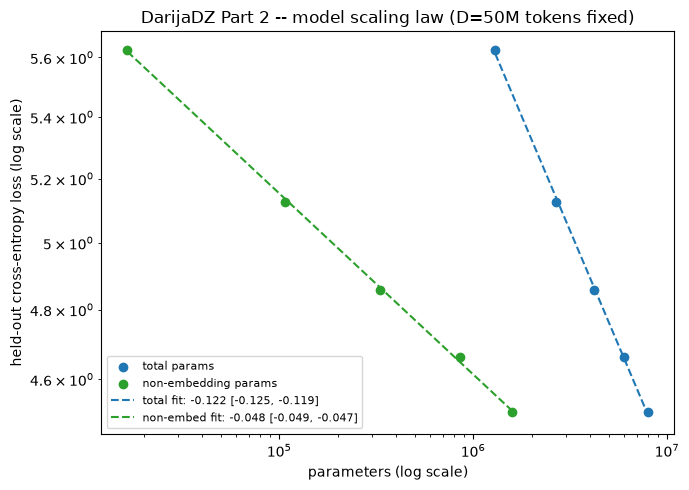

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(results_df["n_params"], results_df["heldout_ce_loss"], color="tab:blue", zorder=3, label="total params")
ax.scatter(results_df["n_params_non_embedding"], results_df["heldout_ce_loss"], color="tab:green", zorder=3, label="non-embedding params")

xs_total = np.linspace(np.log(results_df["n_params"].min()), np.log(results_df["n_params"].max()), 100)
ax.plot(np.exp(xs_total), np.exp(slope_total * xs_total + intercept_total), color="tab:blue", ls="--",
        label=f"total fit: {slope_total:.3f} [{ci_total_low:.3f}, {ci_total_high:.3f}]")

xs_ne = np.linspace(np.log(results_df["n_params_non_embedding"].min()), np.log(results_df["n_params_non_embedding"].max()), 100)
ax.plot(np.exp(xs_ne), np.exp(slope_ne * xs_ne + intercept_ne), color="tab:green", ls="--",
        label=f"non-embed fit: {slope_ne:.3f} [{ci_ne_low:.3f}, {ci_ne_high:.3f}]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("parameters (log scale)")
ax.set_ylabel("held-out cross-entropy loss (log scale)")
ax.set_title("DarijaDZ Part 2 -- model scaling law (D=50M tokens fixed)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(DATA_DIR / "part2_fit.png", dpi=150)
plt.show()

## Where does the total-vs-non-embedding choice start to matter?

Embedding-parameter fraction per model -- DarijaDZ's vocab (20K) is much smaller than
GPT-2's (50K), so this fraction should shrink faster with `d_model` than in a typical
English LM at the same width.

In [6]:
results_df["embedding_fraction"] = 1 - results_df["n_params_non_embedding"] / results_df["n_params"]
results_df[["d_model", "n_params", "n_params_non_embedding", "embedding_fraction"]]

,d_model,n_params,n_params_non_embedding,embedding_fraction
0,32,1298528,16480,0.987309
1,64,2670912,106816,0.960008
2,96,4178592,332448,0.920440
3,128,5981312,853120,0.857369
4,160,7999200,1588960,0.801360


## Discussion (edit after seeing the real numbers above)

- Compare `slope_total` vs `slope_ne`: do they actually differ here, or are they close
  enough that the axis choice doesn't matter much at this parameter scale (a few million
  params)? The lecture's framing suggests the two diverge more as embedding-table cost
  becomes a larger fraction of the total -- check that against the `embedding_fraction`
  column above, which should be largest at the smallest `d_model` and shrink as `d_model`
  grows (embedding cost is `vocab_size * d_model`, linear in `d_model`, while non-embedding
  cost grows roughly cubically under this fixed-aspect-ratio family -- so the fraction
  should shrink fast).
- Check the margin table from earlier against the fitted curve's residuals: does the
  `margin=1.6x` point (largest model, closest to the compute-optimal boundary) sit visibly
  above the fitted line (worse than predicted, consistent with mild data-limitation) or is
  it still on-trend? This is the honest way to tell whether the fixed D=50M budget started
  to bind at the top of this particular sweep, not just assume it didn't because the margin
  was technically above 1x.